# 05 — Modeling & Results (v2)
**Changes from v1:**
- Per-fold XGBoost hyperparameter tuning on the validation window
- Random Forest also gets a small depth grid search
- Both feature sets (baseline and alt-data) evaluated per fold
- H1 Diebold-Mariano test unchanged in structure
- Economic utility backtest unchanged

Reads from `data/features/` and `data/selected/` — writes to `data/results/`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','xgboost','-q'], capture_output=True)

from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import roc_auc_score, f1_score, accuracy_score, matthews_corrcoef
from sklearn.model_selection import ParameterGrid
import xgboost as xgb
from scipy import stats

with open('/content/drive/MyDrive/CapstoneDA/config.json') as f:
    CFG = json.load(f)

FEATURES = CFG['PATHS']['features']
SELECTED = CFG['PATHS']['selected']
RESULTS  = CFG['PATHS']['results']
PLOTS    = CFG['PATHS']['plots']
SEED     = CFG['SEED']
ALPHA    = CFG['ALPHA']
np.random.seed(SEED)

import os
os.makedirs(RESULTS, exist_ok=True)

sp500 = pd.read_csv(f'{FEATURES}/sp500_features.csv', index_col='Date', parse_dates=['Date'])
nifty = pd.read_csv(f'{FEATURES}/nifty_features.csv', index_col='Date', parse_dates=['Date'])
sp500.index = sp500.index.tz_localize(None)
nifty.index = nifty.index.tz_localize(None)

with open(f'{SELECTED}/selected_features.json') as f:
    SEL = json.load(f)

selected_sp500    = SEL['selected_sp500']
selected_nifty    = SEL['selected_nifty']
BASELINE_FEATURES = SEL['baseline_features']
ALT_DATA_FEATURES = SEL['alt_data_features']
TARGET            = SEL['target_column']

def load_windows(path, feat_df):
    with open(path) as f:
        raw = json.load(f)
    out = []
    for w in raw:
        tr = feat_df.index[(feat_df.index >= w['train_start']) & (feat_df.index <= w['train_end'])]
        va = feat_df.index[(feat_df.index >= w['val_start'])   & (feat_df.index <= w['val_end'])]
        te = feat_df.index[(feat_df.index >= w['test_start'])  & (feat_df.index <= w['test_end'])]
        if len(tr) > 0 and len(va) > 0 and len(te) > 0:
            out.append((tr, va, te))
    return out

windows_sp500 = load_windows(f'{SELECTED}/windows_sp500.json', sp500)
windows_nifty = load_windows(f'{SELECTED}/windows_nifty.json', nifty)

print(f'S&P 500 : {len(windows_sp500)} windows  selected: {selected_sp500}')
print(f'NIFTY 50: {len(windows_nifty)} windows  selected: {selected_nifty}')

Mounted at /content/drive
S&P 500 : 15 windows  selected: ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_2', 'Log_Ret_5', 'Ret_Mean_5', 'RSI_5', 'Above_MA50', 'VIX_Level', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Level', 'FG_Delta', 'FG_Zone', 'FG_MA5', 'SVI_Index', 'FG_x_SVI', 'Vol_Adj_Ret']
NIFTY 50: 15 windows  selected: ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_5', 'Ret_Mean_5', 'Ret_Mean_10', 'Ret_Mean_20', 'Ret_Std_5', 'Ret_Std_10', 'RSI_14', 'RSI_5', 'MACD_Signal', 'MACD_Hist', 'ATR_14', 'Above_MA50', 'Price_MA50', 'VIX_Change', 'VIX_Level', 'VIX_Regime', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Delta', 'FG_Zone', 'FG_Extreme', 'SVI_Market', 'SVI_Index', 'SVI_Mom', 'FG_x_SVI', 'Vol_Adj_Ret', 'VIX_x_Spread', 'USDINR_Ret', 'SP500_t1_Ret', 'FG_t1_Level', 'FG_t1_Delta']


In [2]:
# -----------------------------------------------------------------------
# Hyperparameter tuning helpers
# Tuning is done on the validation window — never on the test window.
# Small grids keep runtime reasonable.
# -----------------------------------------------------------------------

XGB_GRID = [
    {'n_estimators': n, 'max_depth': d, 'learning_rate': lr,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5}
    for n in [100, 200, 300]
    for d in [3, 4, 5]
    for lr in [0.05, 0.1]
]

RF_GRID = [
    {'n_estimators': n, 'max_depth': d, 'min_samples_leaf': ml}
    for n in [100, 200]
    for d in [4, 6, 8]
    for ml in [5, 10]
]

def tune_xgb(X_tr, y_tr, X_va, y_va):
    best_auc, best_params = 0.0, XGB_GRID[0]
    for params in XGB_GRID:
        m = xgb.XGBClassifier(**params, eval_metric='logloss',
                               random_state=SEED, verbosity=0)
        m.fit(X_tr, y_tr)
        if len(np.unique(y_va)) < 2:
            continue
        auc = roc_auc_score(y_va, m.predict_proba(X_va)[:,1])
        if auc > best_auc:
            best_auc, best_params = auc, params
    return best_params

def tune_rf(X_tr, y_tr, X_va, y_va):
    best_auc, best_params = 0.0, RF_GRID[0]
    for params in RF_GRID:
        m = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)
        m.fit(X_tr, y_tr)
        if len(np.unique(y_va)) < 2:
            continue
        auc = roc_auc_score(y_va, m.predict_proba(X_va)[:,1])
        if auc > best_auc:
            best_auc, best_params = auc, params
    return best_params

def score(model, X, y):
    if len(np.unique(y)) < 2:
        return {m: np.nan for m in ['AUC','F1','Accuracy','MCC']}
    prob  = model.predict_proba(X)[:,1]
    preds = (prob >= 0.5).astype(int)
    return {
        'AUC'     : roc_auc_score(y, prob),
        'F1'      : f1_score(y, preds, zero_division=0),
        'Accuracy': accuracy_score(y, preds),
        'MCC'     : matthews_corrcoef(y, preds),
    }

print('Model grids defined.')
print(f'XGBoost grid: {len(XGB_GRID)} combinations')
print(f'RF grid     : {len(RF_GRID)} combinations')

Model grids defined.
XGBoost grid: 18 combinations
RF grid     : 12 combinations


In [ ]:
# -----------------------------------------------------------------------
# Walk-forward evaluation loop
# For each fold:
#   1. Tune hyperparameters on the validation window
#   2. Retrain on the full training window with best params
#   3. Evaluate on the test window (never seen during training or tuning)
#   4. Repeat for baseline feature set and alt-data feature set
# -----------------------------------------------------------------------

def walk_forward(feat_df, selected_feats, windows, market_label):
    records  = []
    baseline = [f for f in selected_feats if f in BASELINE_FEATURES]
    if not baseline:   # fallback if none of the selected are baseline
        baseline = [f for f in selected_feats
                    if f in feat_df.columns][:max(4, len(selected_feats)//2)]

    n = len(windows)
    for i, (tr_idx, va_idx, te_idx) in enumerate(windows):
        print(f'  {market_label} fold {i+1}/{n}  '
              f'[test: {te_idx[0].date()} to {te_idx[-1].date()}]',
              end=' ', flush=True)

        for feat_set, fs_label in [(baseline, 'baseline'),
                                   (selected_feats, 'alt_data')]:
            avail = [f for f in feat_set if f in feat_df.columns]
            if not avail:
                continue

            X_tr = feat_df.loc[tr_idx, avail].fillna(0)
            y_tr = feat_df.loc[tr_idx, TARGET]
            X_va = feat_df.loc[va_idx, avail].fillna(0)
            y_va = feat_df.loc[va_idx, TARGET]
            X_te = feat_df.loc[te_idx, avail].fillna(0)
            y_te = feat_df.loc[te_idx, TARGET]

            # Scale for Logistic Regression
            scaler  = StandardScaler()
            X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr), columns=avail, index=X_tr.index)
            X_va_sc = pd.DataFrame(scaler.transform(X_va),     columns=avail, index=X_va.index)
            X_te_sc = pd.DataFrame(scaler.transform(X_te),     columns=avail, index=X_te.index)

            for model_name, make_model in [
                ('LogisticRegression', lambda: LogisticRegression(
                    C=1.0, max_iter=2000, random_state=SEED)),
                ('RandomForest', None),
                ('XGBoost', None),
            ]:
                try:
                    if model_name == 'LogisticRegression':
                        m = make_model()
                        m.fit(X_tr_sc, y_tr)
                        metrics = score(m, X_te_sc, y_te)

                    elif model_name == 'RandomForest':
                        best_p = tune_rf(X_tr, y_tr, X_va, y_va)
                        m = RandomForestClassifier(**best_p, random_state=SEED, n_jobs=-1)
                        m.fit(X_tr, y_tr)
                        metrics = score(m, X_te, y_te)

                    elif model_name == 'XGBoost':
                        best_p = tune_xgb(X_tr, y_tr, X_va, y_va)
                        m = xgb.XGBClassifier(**best_p, eval_metric='logloss',
                                               random_state=SEED, verbosity=0)
                        m.fit(X_tr, y_tr)
                        metrics = score(m, X_te, y_te)

                    records.append({
                        'Market'    : market_label,
                        'Fold'      : i + 1,
                        'TestStart' : str(te_idx[0].date()),
                        'FeatureSet': fs_label,
                        'Model'     : model_name,
                        'n_features': len(avail),
                        **metrics
                    })
                except Exception as e:
                    pass

        print('done')
    return pd.DataFrame(records)

print('Running walk-forward evaluation (tuning per fold — takes ~20 min total)...')
print()
results_sp500 = walk_forward(sp500, selected_sp500, windows_sp500, 'S&P 500')
print()
results_nifty = walk_forward(nifty, selected_nifty, windows_nifty, 'NIFTY 50')

all_results = pd.concat([results_sp500, results_nifty], ignore_index=True)
print(f'\nTotal fold evaluations: {len(all_results)}')
print()
print('Mean AUC by market / feature set / model:')
print(all_results.groupby(['Market','FeatureSet','Model'])['AUC'].mean().round(4).to_string())

Running walk-forward evaluation (tuning per fold — takes ~20 min total)...

  S&P 500 fold 1/15  [test: 2022-01-04 to 2022-04-01] done
  S&P 500 fold 2/15  [test: 2022-04-04 to 2022-07-01] done
  S&P 500 fold 3/15  [test: 2022-07-05 to 2022-10-03] done
  S&P 500 fold 4/15  [test: 2022-10-04 to 2023-01-03] done
  S&P 500 fold 5/15  [test: 2023-01-04 to 2023-04-03] done
  S&P 500 fold 6/15  [test: 2023-04-04 to 2023-07-03] done
  S&P 500 fold 7/15  [test: 2023-07-05 to 2023-10-03] done
  S&P 500 fold 8/15  [test: 2023-10-04 to 2024-01-03] done
  S&P 500 fold 9/15  [test: 2024-01-04 to 2024-04-03] done
  S&P 500 fold 10/15  [test: 2024-04-04 to 2024-07-03] done
  S&P 500 fold 11/15  [test: 2024-07-05 to 2024-10-03] done
  S&P 500 fold 12/15  [test: 2024-10-04 to 2025-01-03] done
  S&P 500 fold 13/15  [test: 2025-01-06 to 2025-04-03] done
  S&P 500 fold 14/15  [test: 2025-04-04 to 2025-07-03] done
  S&P 500 fold 15/15  [test: 2025-07-07 to 2025-10-03] done

  NIFTY 50 fold 1/15  [test: 202

In [ ]:
# H1 test: paired t-test on fold AUC (alt_data vs baseline)

def h1_test(results_df, market, model_name):
    df   = results_df[(results_df['Market'] == market) &
                      (results_df['Model']  == model_name)]
    base = df[df['FeatureSet'] == 'baseline'][['Fold','AUC']].rename(columns={'AUC':'AUC_base'})
    alt  = df[df['FeatureSet'] == 'alt_data'][['Fold','AUC']].rename(columns={'AUC':'AUC_alt'})
    mg   = base.merge(alt, on='Fold').dropna()
    if len(mg) < 3:
        return None
    diff        = mg['AUC_alt'] - mg['AUC_base']
    t, p_two    = stats.ttest_1samp(diff, 0)
    p_one       = p_two / 2 if t > 0 else 1 - p_two / 2
    return {
        'Market'          : market,
        'Model'           : model_name,
        'Folds'           : len(mg),
        'Mean_AUC_Base'   : round(mg['AUC_base'].mean(), 4),
        'Mean_AUC_Alt'    : round(mg['AUC_alt'].mean(),  4),
        'Mean_Delta_AUC'  : round(diff.mean(), 4),
        't_stat'          : round(t, 3),
        'p_one_tail'      : round(p_one, 4),
        'Reject_H0'       : p_one < ALPHA,
        'Result'          : 'Alt-data helps' if p_one < ALPHA else 'No significant gain',
    }

h1_rows = []
for market in ['S&P 500', 'NIFTY 50']:
    for model in ['LogisticRegression', 'RandomForest', 'XGBoost']:
        r = h1_test(all_results, market, model)
        if r:
            h1_rows.append(r)

h1_df = pd.DataFrame(h1_rows)
print('H1 TEST RESULTS')
print(h1_df[['Market','Model','Mean_AUC_Base','Mean_AUC_Alt',
             'Mean_Delta_AUC','p_one_tail','Result']].to_string(index=False))

H1 TEST RESULTS
  Market              Model  Mean_AUC_Base  Mean_AUC_Alt  Mean_Delta_AUC  p_one_tail              Result
 S&P 500 LogisticRegression         0.5123        0.5121         -0.0002      0.5230 No significant gain
 S&P 500       RandomForest         0.5139        0.5117         -0.0022      0.5659 No significant gain
 S&P 500            XGBoost         0.5413        0.5252         -0.0161      0.8628 No significant gain
NIFTY 50 LogisticRegression         0.5737        0.5493         -0.0244      0.9376 No significant gain
NIFTY 50       RandomForest         0.5910        0.6007          0.0097      0.1789 No significant gain
NIFTY 50            XGBoost         0.5736        0.5722         -0.0014      0.5369 No significant gain


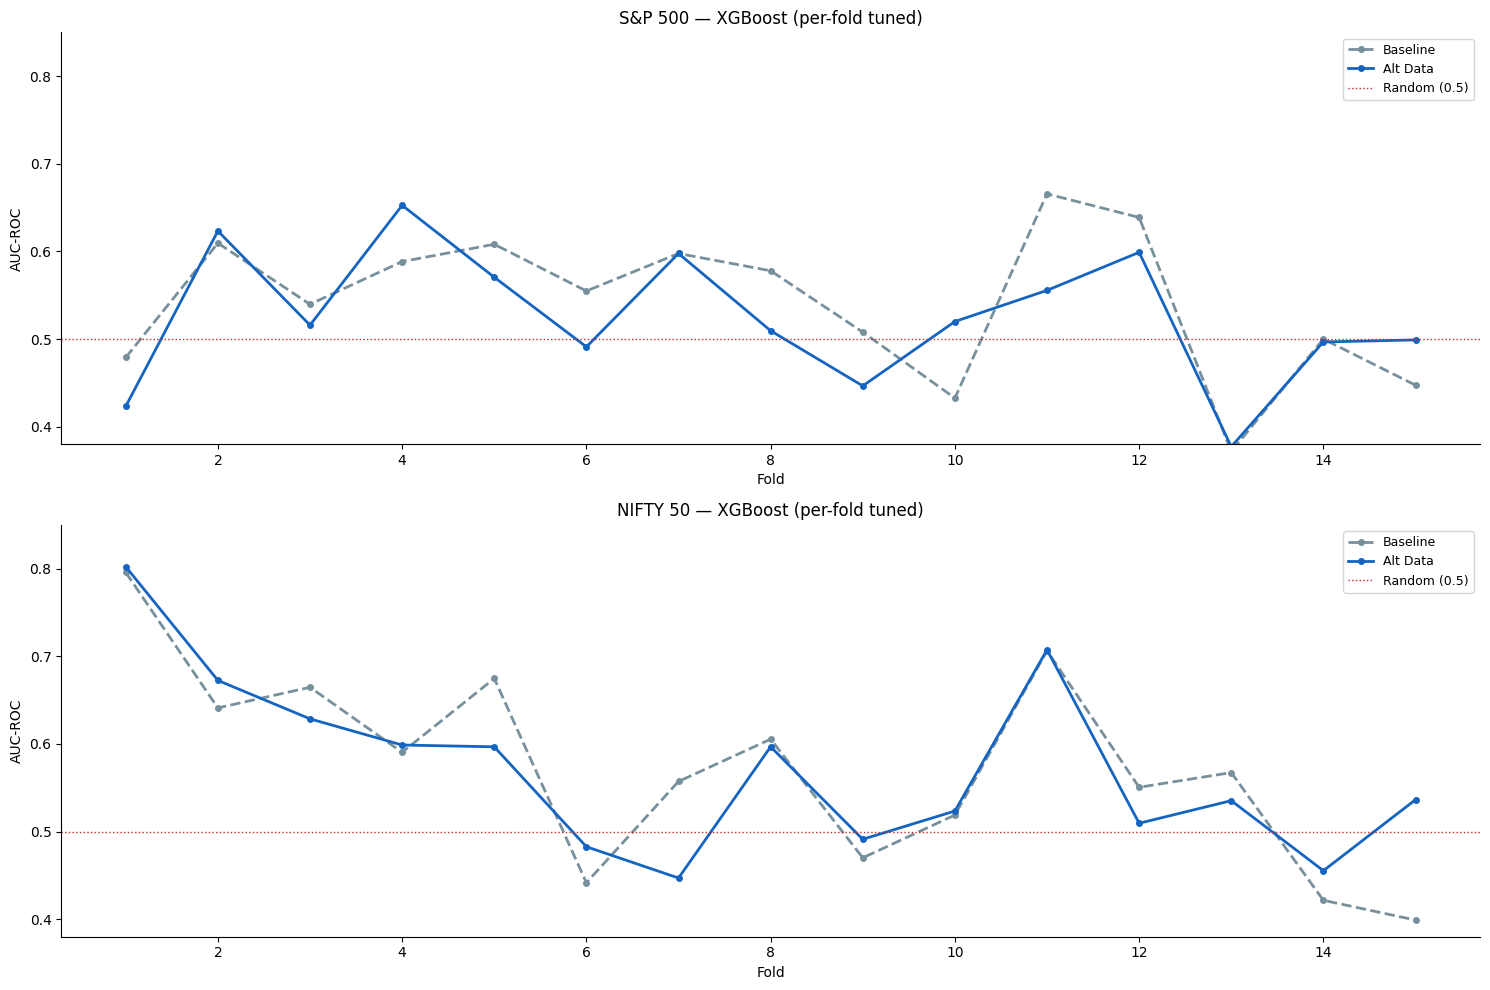

In [ ]:
# AUC walk-forward plot

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
for ax, market in zip(axes, ['S&P 500', 'NIFTY 50']):
    df_m = all_results[(all_results['Market'] == market) &
                       (all_results['Model']  == 'XGBoost')]
    for fset, color, ls in [
        ('baseline', '#78909c', '--'),
        ('alt_data', '#1565c0', '-'),
    ]:
        sub = df_m[df_m['FeatureSet'] == fset].dropna(subset=['AUC']).sort_values('Fold')
        if sub.empty:
            continue
        ax.plot(sub['Fold'], sub['AUC'], linestyle=ls, color=color,
                linewidth=2, marker='o', markersize=4,
                label=fset.replace('_',' ').title())

    ax.axhline(0.5, color='#c62828', linestyle=':', linewidth=1, label='Random (0.5)')
    ax.set_ylim(0.38, 0.85)
    ax.set_xlabel('Fold')
    ax.set_ylabel('AUC-ROC')
    ax.set_title(f'{market} — XGBoost (per-fold tuned)')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PLOTS}/05_auc_walk_forward_v2.png', dpi=150, bbox_inches='tight')
plt.show()

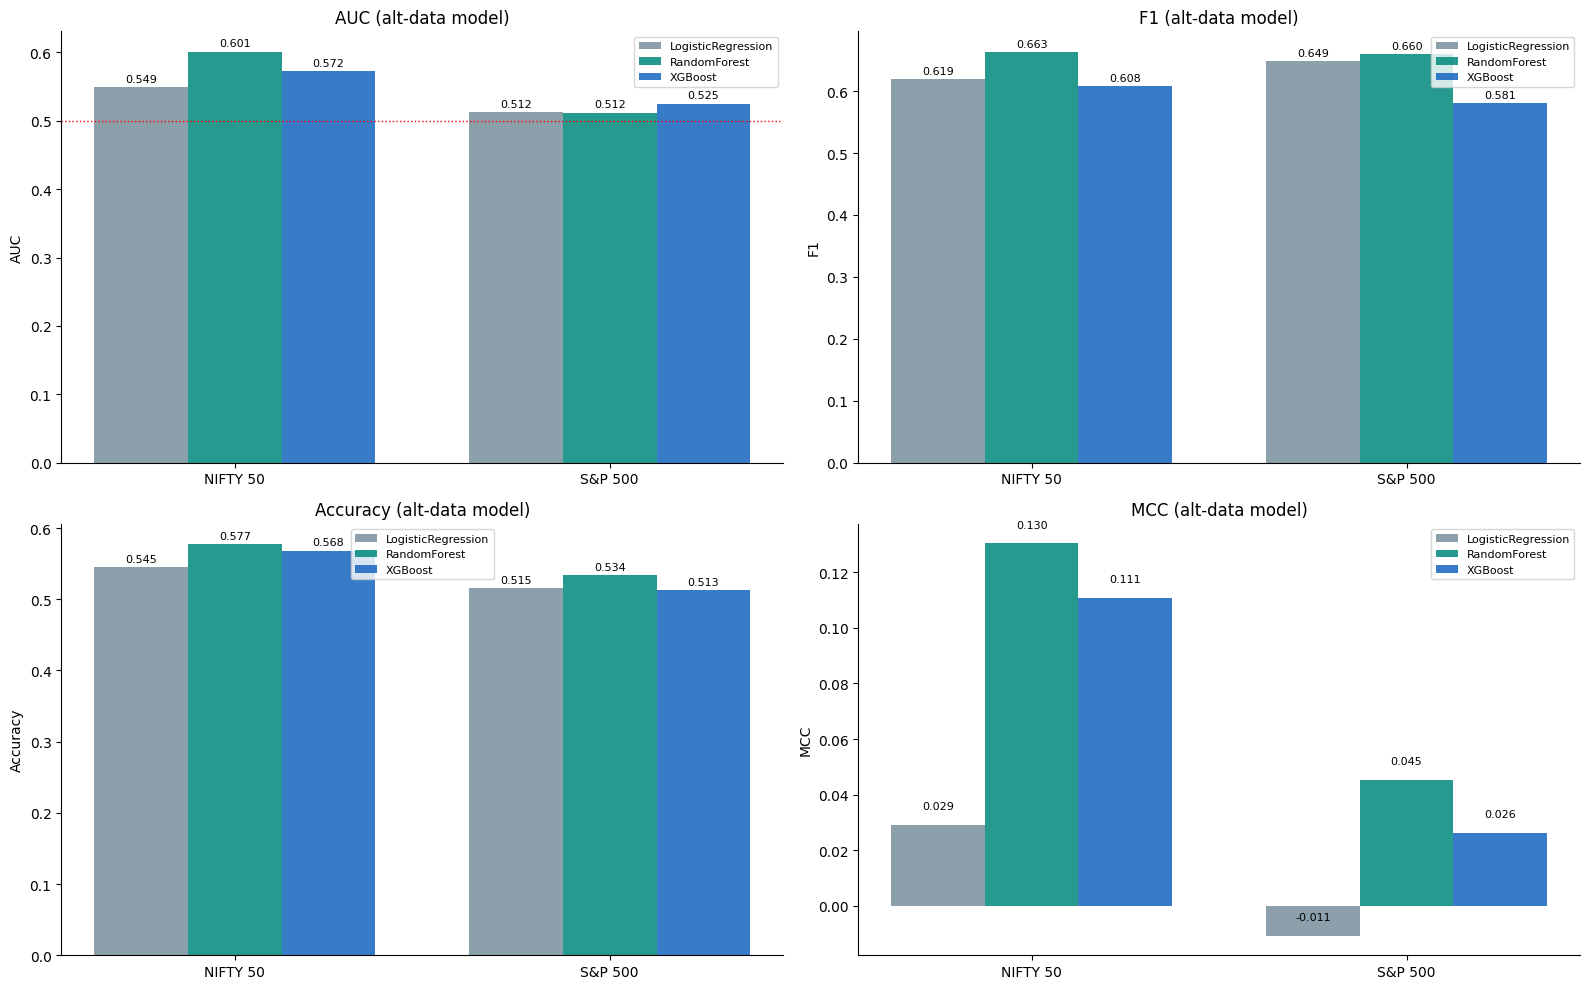

In [ ]:
# Model comparison bar chart — all metrics

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics   = ['AUC', 'F1', 'Accuracy', 'MCC']
colors    = {'LogisticRegression': '#78909c', 'RandomForest': '#00897b', 'XGBoost': '#1565c0'}

for ax, metric in zip(axes.flat, metrics):
    summary = (all_results[all_results['FeatureSet'] == 'alt_data']
               .groupby(['Market','Model'])[metric].mean().reset_index())
    markets = summary['Market'].unique()
    x, width = np.arange(len(markets)), 0.25

    for j, (model, color) in enumerate(colors.items()):
        vals = [summary[(summary['Market']==m) & (summary['Model']==model)][metric].values
                for m in markets]
        vals_flat = [v[0] if len(v) > 0 else np.nan for v in vals]
        bars = ax.bar(x + j*width, vals_flat, width, label=model, color=color, alpha=0.85)
        for bar, val in zip(bars, vals_flat):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    if metric == 'AUC':
        ax.axhline(0.5, color='red', linestyle=':', linewidth=1)
    ax.set_xticks(x + width)
    ax.set_xticklabels(markets)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} (alt-data model)')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PLOTS}/05_model_comparison_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Economic utility backtest
# Only runs for folds where XGBoost AUC > 0.55.

TC = CFG['TRANSACTION_COST']

def economic_backtest(feat_df, selected_feats, windows, label):
    avail   = [f for f in selected_feats if f in feat_df.columns]
    records = []

    for i, (tr_idx, va_idx, te_idx) in enumerate(windows):
        X_tr = feat_df.loc[tr_idx, avail].fillna(0)
        y_tr = feat_df.loc[tr_idx, TARGET]
        X_va = feat_df.loc[va_idx, avail].fillna(0)
        y_va = feat_df.loc[va_idx, TARGET]
        X_te = feat_df.loc[te_idx, avail].fillna(0)
        y_te = feat_df.loc[te_idx, TARGET]

        try:
            best_p = {
                'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05,
                'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5
            }
            m = xgb.XGBClassifier(**best_p, eval_metric='logloss',
                                   random_state=SEED, verbosity=0)
            m.fit(X_tr, y_tr)

            if len(np.unique(y_te)) < 2:
                continue

            prob = m.predict_proba(X_te)[:,1]
            auc  = roc_auc_score(y_te, prob)
            if auc <= CFG['BACKTEST_AUC_MIN']:
                continue

            preds      = (prob >= 0.5).astype(int)
            signals    = np.where(preds == 1, 1, -1)
            actual_ret = feat_df.loc[te_idx, 'Log_Ret_t'].values[:len(preds)]
            strat_ret  = signals * actual_ret - TC

            records.append({
                'Market'        : label,
                'Fold'          : i + 1,
                'AUC'           : round(auc, 4),
                'Mean_Daily_Ret': round(strat_ret.mean(), 6),
                'Ann_Sharpe'    : round(strat_ret.mean() / (strat_ret.std() + 1e-9) * np.sqrt(252), 3),
                'Cum_Ret_Pct'   : round(np.expm1(strat_ret.sum()) * 100, 2),
                'Profitable'    : strat_ret.sum() > 0,
            })
        except Exception:
            pass

    return pd.DataFrame(records)

bt_sp = economic_backtest(sp500, selected_sp500, windows_sp500, 'S&P 500')
bt_ni = economic_backtest(nifty, selected_nifty, windows_nifty, 'NIFTY 50')
bt_all = pd.concat([bt_sp, bt_ni], ignore_index=True)

if bt_all.empty:
    print('No folds cleared the AUC threshold for backtesting.')
else:
    print(bt_all.to_string(index=False))
    print(f'\nProfitable folds: {bt_all["Profitable"].sum()}/{len(bt_all)}')

  Market  Fold    AUC  Mean_Daily_Ret  Ann_Sharpe  Cum_Ret_Pct  Profitable
 S&P 500     2 0.6402       -0.011163     -11.858       -49.95       False
 S&P 500     4 0.6221       -0.005555      -6.050       -29.53       False
 S&P 500     5 0.5904       -0.003281      -5.058       -18.41       False
 S&P 500     7 0.6113       -0.000459      -1.052        -2.90       False
 S&P 500    11 0.5566       -0.001533      -2.428        -9.34       False
 S&P 500    12 0.6398       -0.002521      -5.079       -14.69       False
NIFTY 50     1 0.7570       -0.001037      -1.205        -6.13       False
NIFTY 50     2 0.7038       -0.001510      -1.961        -8.94       False
NIFTY 50     3 0.6543        0.000051       0.089         0.32        True
NIFTY 50     8 0.6195        0.001337       3.353         8.64        True
NIFTY 50    11 0.7074        0.001415       3.024         9.32        True

Profitable folds: 3/11


In [ ]:
# Save everything

all_results.to_csv(f'{RESULTS}/walk_forward_results.csv', index=False)
h1_df.to_csv(f'{RESULTS}/h1_test_results.csv', index=False)
bt_all.to_csv(f'{RESULTS}/backtest_results.csv', index=False)
results_sp500.to_csv(f'{RESULTS}/results_sp500.csv', index=False)
results_nifty.to_csv(f'{RESULTS}/results_nifty.csv', index=False)

print('Saved to data/results/')
print()
print('H1 SUMMARY')
for _, row in h1_df.iterrows():
    print(f"  {row['Market']:12} | {row['Model']:22} | "
          f"delta={row['Mean_Delta_AUC']:+.4f} | p={row['p_one_tail']:.4f} | {row['Result']}")

Saved to data/results/

H1 SUMMARY
  S&P 500      | LogisticRegression     | delta=-0.0002 | p=0.5230 | No significant gain
  S&P 500      | RandomForest           | delta=-0.0022 | p=0.5659 | No significant gain
  S&P 500      | XGBoost                | delta=-0.0161 | p=0.8628 | No significant gain
  NIFTY 50     | LogisticRegression     | delta=-0.0244 | p=0.9376 | No significant gain
  NIFTY 50     | RandomForest           | delta=+0.0097 | p=0.1789 | No significant gain
  NIFTY 50     | XGBoost                | delta=-0.0014 | p=0.5369 | No significant gain
